# The business and data visualization context
The audience of this presentation is the head director of a movie production  studio. I will present 5 insights from the IMDB Top 1000 Movie (see reference [1]) which are informative for raising movie's profit. Several graphs and charts are presented for a quicker and better understanding of the insights. This dataset includes numerical and textual data.


# data exploration discussion
It's a dataset of 1000 rows and 16 columns. The dataset is fairly clean, although it has some missing values in few columns. In the preprocessing section the data curation technique used to fill the missing values is explained in detail.

In [1]:
#Connect colab to personal drive file storage
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#Import neccessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
from scipy.stats import gaussian_kde

In [3]:
# This class was adopted from [3] in References section
class BubbleChart:
    def __init__(self, area, bubble_spacing=0):
        """
        Setup for bubble collapse.

        Parameters
        ----------
        area : array-like
            Area of the bubbles.
        bubble_spacing : float, default: 0
            Minimal spacing between bubbles after collapsing.

        Notes
        -----
        If "area" is sorted, the results might look weird.
        """
        area = np.asarray(area)
        r = np.sqrt(area / np.pi)

        self.bubble_spacing = bubble_spacing
        self.bubbles = np.ones((len(area), 4))
        self.bubbles[:, 2] = r
        self.bubbles[:, 3] = area
        self.maxstep = 2 * self.bubbles[:, 2].max() + self.bubble_spacing
        self.step_dist = self.maxstep / 2

        # calculate initial grid layout for bubbles
        length = np.ceil(np.sqrt(len(self.bubbles)))
        grid = np.arange(length) * self.maxstep
        gx, gy = np.meshgrid(grid, grid)
        self.bubbles[:, 0] = gx.flatten()[:len(self.bubbles)]
        self.bubbles[:, 1] = gy.flatten()[:len(self.bubbles)]

        self.com = self.center_of_mass()

    def center_of_mass(self):
        return np.average(
            self.bubbles[:, :2], axis=0, weights=self.bubbles[:, 3]
        )

    def center_distance(self, bubble, bubbles):
        return np.hypot(bubble[0] - bubbles[:, 0],
                        bubble[1] - bubbles[:, 1])

    def outline_distance(self, bubble, bubbles):
        center_distance = self.center_distance(bubble, bubbles)
        return center_distance - bubble[2] - \
            bubbles[:, 2] - self.bubble_spacing

    def check_collisions(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return len(distance[distance < 0])

    def collides_with(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return np.argmin(distance, keepdims=True)

    def collapse(self, n_iterations=50):
        """
        Move bubbles to the center of mass.

        Parameters
        ----------
        n_iterations : int, default: 50
            Number of moves to perform.
        """
        for _i in range(n_iterations):
            moves = 0
            for i in range(len(self.bubbles)):
                rest_bub = np.delete(self.bubbles, i, 0)
                # try to move directly towards the center of mass
                # direction vector from bubble to the center of mass
                dir_vec = self.com - self.bubbles[i, :2]

                # shorten direction vector to have length of 1
                dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))

                # calculate new bubble position
                new_point = self.bubbles[i, :2] + dir_vec * self.step_dist
                new_bubble = np.append(new_point, self.bubbles[i, 2:4])

                # check whether new bubble collides with other bubbles
                if not self.check_collisions(new_bubble, rest_bub):
                    self.bubbles[i, :] = new_bubble
                    self.com = self.center_of_mass()
                    moves += 1
                else:
                    # try to move around a bubble that you collide with
                    # find colliding bubble
                    for colliding in self.collides_with(new_bubble, rest_bub):
                        # calculate direction vector
                        dir_vec = rest_bub[colliding, :2] - self.bubbles[i, :2]
                        dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))
                        # calculate orthogonal vector
                        orth = np.array([dir_vec[1], -dir_vec[0]])
                        # test which direction to go
                        new_point1 = (self.bubbles[i, :2] + orth *
                                      self.step_dist)
                        new_point2 = (self.bubbles[i, :2] - orth *
                                      self.step_dist)
                        dist1 = self.center_distance(
                            self.com, np.array([new_point1]))
                        dist2 = self.center_distance(
                            self.com, np.array([new_point2]))
                        new_point = new_point1 if dist1 < dist2 else new_point2
                        new_bubble = np.append(new_point, self.bubbles[i, 2:4])
                        if not self.check_collisions(new_bubble, rest_bub):
                            self.bubbles[i, :] = new_bubble
                            self.com = self.center_of_mass()

            if moves / len(self.bubbles) < 0.1:
                self.step_dist = self.step_dist / 2

    def plot(self, ax, labels, colors):
        """
        Draw the bubble plot.

        Parameters
        ----------
        ax : matplotlib.axes.Axes
        labels : list
            Labels of the bubbles.
        colors : list
            Colors of the bubbles.
        """
        for i in range(len(self.bubbles)):
            circ = plt.Circle(
                self.bubbles[i, :2], self.bubbles[i, 2], color=colors[i])
            ax.add_patch(circ)
            ax.text(*self.bubbles[i, :2], labels[i],
                    horizontalalignment='center', verticalalignment='center')

In [4]:
movie_dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/imdb_top_1000.csv')

In [5]:
# ––––––––––––––––––––
#     Overview
# ––––––––––––––––––––

#movie_dataset.head(2)
movie_dataset.shape

(1000, 16)

# Preprocessing

This section includes the following preprocessing:


*   Checking for duplicates: since there are two different movies with the same name, they will be left as they are.
*   There is one movie with a non-numeric release year. It is corrected manually after finding the release year online.
*   Release_Year, Gross and Runtime columns are converted to int and float
*   There are 169 null cells in Gross column. Manual replacement of these values is avoided as it is not a professional approach. Instead, a seperate column, 'Decade', is made to put each movie into the appropriate decade based on their release year. The null values in Gross are then filled with the median value of the movies in the respective decade. After this process, 6 cells still remain null, two of which were filled manually according to [2] (see the References). The entire dataset except the remaing 4 rows with a null value in Gross is copied into another dataset. This is so the project could still benefit from the other information of those 4 movies.



In [6]:
# This shows each duplicated title + how many times it appears
duplicated_titles = movie_dataset['Series_Title'].value_counts()
duplicated_titles = duplicated_titles[duplicated_titles > 1]
print(duplicated_titles)
movie_dataset[movie_dataset['Series_Title'] == 'Drishyam']

Series_Title
Drishyam    2
Name: count, dtype: int64


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
87,https://m.media-amazon.com/images/M/MV5BYmY3Mz...,Drishyam,2013,U,160 min,"Crime, Drama, Thriller",8.3,A man goes to extreme lengths to save his fami...,NaN,Jeethu Joseph,Mohanlal,Meena,Asha Sharath,Ansiba,30722,NaN
136,https://m.media-amazon.com/images/M/MV5BYmJhZm...,Drishyam,2015,UA,163 min,"Crime, Drama, Mystery",8.2,Desperate measures are taken by a man who trie...,NaN,Nishikant Kamat,Ajay Devgn,Shriya Saran,Tabu,Rajat Kapoor,70367,"739,478"


In [7]:
# Checks nulls
nan_count = movie_dataset.isnull().sum()
print(nan_count)

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64


In [8]:
# Find where release year is not a number
movie_dataset[movie_dataset['Released_Year'] == 'PG']

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
966,https://m.media-amazon.com/images/M/MV5BNjEzYj...,Apollo 13,PG,U,140 min,"Adventure, Drama, History",7.6,NASA must devise a strategy to return Apollo 1...,77.0,Ron Howard,Tom Hanks,Bill Paxton,Kevin Bacon,Gary Sinise,269197,"173,837,933"


In [9]:
# Correct the release year
movie_dataset['Released_Year'] = movie_dataset['Released_Year'].replace('PG', '1995')

In [10]:
# Print titles where Gross is missing
print(movie_dataset[movie_dataset['Gross'].isnull()]['Series_Title'])

18                   Hamilton
20            Soorarai Pottru
30                    Seppuku
32      It's a Wonderful Life
46             Hotaru no haka
                ...          
993                    Blowup
995    Breakfast at Tiffany's
996                     Giant
998                  Lifeboat
999              The 39 Steps
Name: Series_Title, Length: 169, dtype: object


In [11]:
# Removes commas and converts to int or float
movie_dataset['Released_Year'] = movie_dataset['Released_Year'].astype(int)
movie_dataset['Gross'] = movie_dataset['Gross'].str.replace(',', '', regex=False).astype(float)
movie_dataset['Runtime'] = movie_dataset['Runtime'].str.replace(' min', '').astype(int)

In [12]:
# 1. Create the decade column
movie_dataset['Decade'] = (movie_dataset['Released_Year'] // 10) * 10

# 2. Fill missing Gross with median of the same decade
movie_dataset['Gross'] = movie_dataset['Gross'].fillna(
    movie_dataset.groupby('Decade')['Gross'].transform('median'))

In [13]:
print(movie_dataset[movie_dataset['Gross'].isnull()]['Series_Title'])

18                       Hamilton
20                Soorarai Pottru
205                          Soul
464                   Dil Bechara
612    The Trial of the Chicago 7
613                          Druk
Name: Series_Title, dtype: object


In [14]:
movie_dataset.loc[movie_dataset['Series_Title'] == 'Hamilton', 'Gross'] = 16946377
movie_dataset.loc[movie_dataset['Series_Title'] == 'Soul', 'Gross'] = 946154

In [15]:
nan_count = movie_dataset.isnull().sum()
print(nan_count)

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross              4
Decade             0
dtype: int64


In [16]:
# Keeps only rows where Gross is not null
movie_df = movie_dataset.dropna(subset=['Gross'])

In [17]:
# Top 10 most profitable movies
top10gross = movie_df.sort_values(by="Gross", ascending=False).head(10)
#print(top10gross)
top10gross.shape

(10, 17)

# Explanatory Data Analysis

The design setting is written in one cell for each liberary in the beggining to avoid repetition and ensure consistency.

In [18]:
# Design setting for Matplotlib
plt.rcParams.update({
    'figure.figsize':        (10, 5),
    'axes.grid':             False,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.facecolor':        'white',
    'axes.titlepad':         35,
    'ytick.color':           '#202020',
    'xtick.color':           '#202020',
    'lines.color':           '#202020',
    'axes.labelcolor':       '#202020',
    'axes.titlesize':        20,
    'axes.titlelocation':    'left',
    'axes.titlecolor':       '#1f1f1f'

})

In [19]:
# Design setting for Plotly
pio.templates["plotly_white"].layout.update(
    title=dict(
        font=dict(color="#005182", size=25),
    subtitle=dict(
        font=dict(color="#3c3c3c", size=14),
        ),
    ),

    xaxis=dict(
        title_font_color = "#777777",
        tickfont_color   = "#777777"
    ),
    yaxis=dict(
        title_font_color = "#777777",
        tickfont_color   = "#777777"
    ),
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    width=1300,
    height=500
)

Layout({
    'annotationdefaults': {'arrowcolor': '#2a3f5f', 'arrowhead': 0, 'arrowwidth': 1},
    'autotypenumbers': 'strict',
    'coloraxis': {'colorbar': {'outlinewidth': 0, 'ticks': ''}},
    'colorscale': {'diverging': [[0, '#8e0152'], [0.1, '#c51b7d'], [0.2,
                                 '#de77ae'], [0.3, '#f1b6da'], [0.4, '#fde0ef'],
                                 [0.5, '#f7f7f7'], [0.6, '#e6f5d0'], [0.7,
                                 '#b8e186'], [0.8, '#7fbc41'], [0.9, '#4d9221'],
                                 [1, '#276419']],
                   'sequential': [[0.0, '#0d0887'], [0.1111111111111111,
                                  '#46039f'], [0.2222222222222222, '#7201a8'],
                                  [0.3333333333333333, '#9c179e'],
                                  [0.4444444444444444, '#bd3786'],
                                  [0.5555555555555556, '#d8576b'],
                                  [0.6666666666666666, '#ed7953'],
                           

# Insight 1

This chart demonstrate that volume does not equal to financial value. In today's competitive market, making a few massive cultural and commercial "events" generate more revenue for the studio than making many respectable movies.


In [20]:
# ––––––––––––––––––––
#   Prepare The Data
# ––––––––––––––––––––
director_stats = movie_df.groupby('Director', as_index=False).agg(
    Movie_Count = ('Series_Title', 'count'),
    Total_Gross = ('Gross', 'sum')
)
top3 = director_stats.nlargest(3, 'Movie_Count').sort_values('Total_Gross', ascending=False)



# ––––––––––––––––––––
#       Plotting
# ––––––––––––––––––––

color_map = {
    top3['Director'].iloc[0]: '#00659b',
    top3['Director'].iloc[1]: '#5cb0d0',
    top3['Director'].iloc[2]: '#8a8a8a'
}

def format_gross(value):
    if value >= 1e9:
        return f"${value / 1e9:.1f}B"
    elif value >= 1e6:
        return f"${value / 1e6:.1f}M"
    else:
        return f"${value:,.0f}"

fig = px.bar(
    top3,
    x='Total_Gross',
    y=['Top 3 Directors'] * len(top3), # repeat label for each row
    color='Director',
    orientation='h',
    text=top3.apply(lambda r: f"{r['Director']}<br>{format_gross(r['Total_Gross'])}<br>{r['Movie_Count']} films", axis=1),
    color_discrete_map=color_map
)
fig.update_layout(
    title=dict(
        text="Steven Spielberg, The Richest Director",
        subtitle=dict(text="Total gross of the top 3 most prolific directors")
),
    xaxis_title='Total Gross ($)', xaxis_showticklabels=False,
    yaxis_title='Directors', yaxis_showticklabels=False,
    template='plotly_white', barmode='stack', showlegend=False, height=300,
    margin=dict(t=120)

)
fig.update_traces(textposition='inside', insidetextanchor='middle', textfont_color='white')
fig.show()

**Code Explanation**

In the prepration process, the number of each directors' movie count and sum of thier gross is calculated and stored in a dataset. Then the list is sorted from the director with most total gross to least. The top three directors of the sorted list is plotted in a single bar chart using Plotly.

**Data Insight**

The data shows Steven Spielberg to be the director with the most total gross of 2.5 billion dollar, massively far from the second and third directors, Hayao Miyazaki and Alfred Hitchcock, with total gross of 175.7 and 136.2 million dollar respectively. What is noteworthy in this representation is the fact that the number of movies produced by these directors had little impact on their total earning

**The Story**

A few blockbuster hits can outweigh decades of steady output.

Steven Spielberg is the richest director in the world. Only in this dataset, he has a total gross of 2.5 billion dollar that is massively more than the total revenue of the second and third rishest directors of this dataset combined. The fact that the number of movies directed had, surprisingly, little influence on total earing makes this chart even more striking.

By studying Spielberg work we learn about a couple of factors that brought him such wealth:


1.   instead of spreading resources accross several mid-budget project, it is more beneficial to go all-in for fewer but high-ambition films.
2.   betting on event-level movies can deliver outstanding returns
3.   having creative ambition


* Action Statement: Don't aim to make the most movies, but to make those that matter most.. with a touch of Spielberg-style, perhaps!

# Insight 2

Actors are the image of stories. Their performance can make a huge difference in the success of a movie. This insight helps the studio to learn about those actors who stood the test of time by appearing in the movie list more than others.

In [21]:
# Filter the years
df = movie_dataset[movie_dataset['Released_Year'].astype(str).str[:4].astype(int).between(2010, 2020)]

# Prepare top 3 for each star column
stars = ['Star1', 'Star2', 'Star3', 'Star4']
top_data = {}
xtitle = ['1st Star', '2nd Star', '3rd Star', '4th Star']


for star in stars:
    top_data[star] = df[star].value_counts().head(3)
"""
# Create 1×4 grid
fig, axes = plt.subplots(1, 4, figsize=(13, 5), sharey=False)
fig.suptitle('Who should we look for \nTop 3 Actors in the last 10 years', fontsize=16)

# Plot each subplot
for i, star in enumerate(stars):
    ax = axes[i]
    counts = top_data[star]
    names = counts.index
    values = counts.values

    ax.barh(names, values, color='#003d80', height=0.8)
    ax.set_title(xtitle[i], fontsize=11, pad=10)
    ax.invert_yaxis()  # highest on top

    # Add count labels
    #for j, v in enumerate(values):
        #ax.text(v + 0.3, j, str(v), va='center', fontsize=10)

# Final touches
plt.tight_layout(rect=[0, 0, 1, 0.96])  # make room for suptitle

plt.show()"""

"\n# Create 1×4 grid\nfig, axes = plt.subplots(1, 4, figsize=(13, 5), sharey=False)\nfig.suptitle('Who should we look for \nTop 3 Actors in the last 10 years', fontsize=16)\n\n# Plot each subplot\nfor i, star in enumerate(stars):\n    ax = axes[i]\n    counts = top_data[star]\n    names = counts.index\n    values = counts.values\n\n    ax.barh(names, values, color='#003d80', height=0.8)\n    ax.set_title(xtitle[i], fontsize=11, pad=10)\n    ax.invert_yaxis()  # highest on top\n\n    # Add count labels\n    #for j, v in enumerate(values):\n        #ax.text(v + 0.3, j, str(v), va='center', fontsize=10)\n\n# Final touches\nplt.tight_layout(rect=[0, 0, 1, 0.96])  # make room for suptitle\n\nplt.show()"

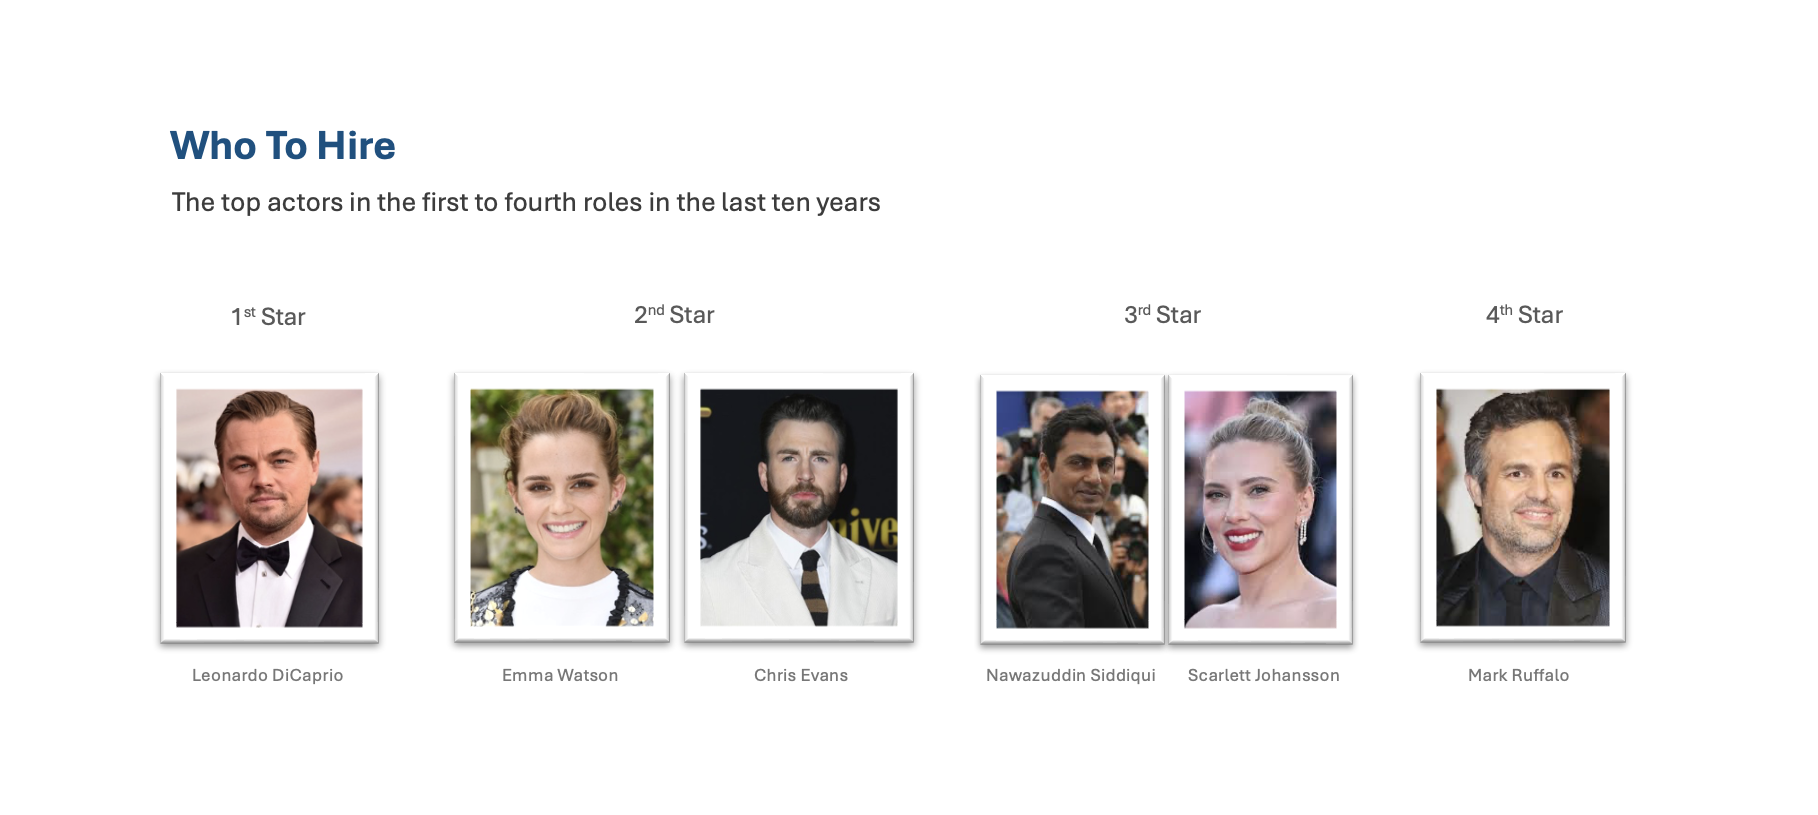

**Code Explanation**

The code first filter the movies that were released between 2010 to 2020. Then it calculates which actors appeared most frequently in the filtered movie dataset for the 1st, 2nd, 3rd and 4th role.

**Data Insight**

The data shows Leonardo DiCaprio as the first role with most appearance, Emma Watson and Chris Evans in the second role, Nawazuddin Siddiqui and Scarlett Johansson in the third role, and Mark Ruffalo in fourth.

**The Story**

Between 2010 and 2020, the movie industry was introduced to a new generation of stars who became the defining faces of the decade.

For the first-role star stands Leonardo DiCaprio whoes powerful performance in movies like Inception and The Revenant made him appear in more movies than anyone else in this prestigious list.

Tied for the second-role actor, Emma Watson with her graceful transition from a beloved child star to a leading woman, and Chris Evans, the ultimate symbol of hiroism as Captain America defined very different corners of cinema.

Sharing the third-star. spot are two versatile talents, Nawazuddin Siddiqui and Scarlett Johansson.

And finally, Mark Ruffalo, one of the most respected dramatic actors of his time is placed for the best fourth-role star.

From billion-dollar blockbusters to intimate indian dramas, these five actors shaped the cinematic landscape of the 2010s.

* Action Statement: Considering these actors during the casting process is highly recommended.

# Insight 3

This insight informs the audience on what genre of movie is more likely to generate greater revenue for the studio.

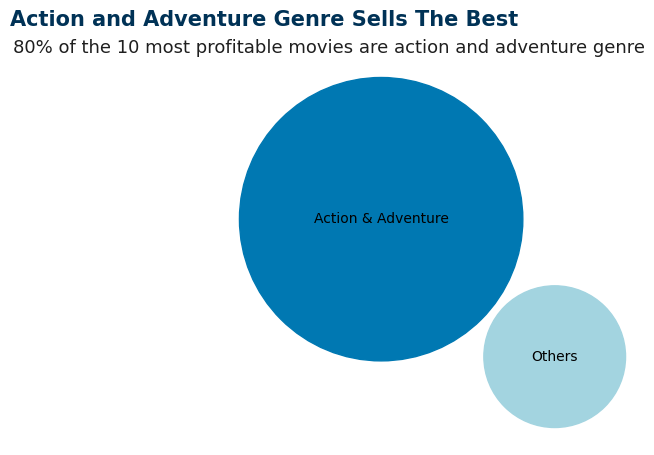

In [22]:
# ––––––––––––––––––––
#   Prepare The Data
# ––––––––––––––––––––

# Movies containing BOTH "Action" and "Adventure"
action_adventure = top10gross[
    top10gross["Genre"].str.contains("Action") &
    top10gross["Genre"].str.contains("Adventure")
]

# Movies that do not contain both
others = top10gross.drop(action_adventure.index)
count_action_adv = len(action_adventure)
count_others = len(others)



# ––––––––––––––––––––
#       Plotting
# ––––––––––––––––––––

labels = ["Action & Adventure", "Others"]
areas = [count_action_adv, count_others]
colors = ["#0078b2", "#a3d4e0"]

bubble_chart = BubbleChart(area=areas, bubble_spacing=0.1)
bubble_chart.collapse()

fig, ax = plt.subplots(subplot_kw=dict(aspect="equal"))

bubble_chart.plot(ax, labels, colors)

ax.axis("off")
ax.relim()
ax.autoscale_view()


fig.suptitle(
    "Action and Adventure Genre Sells The Best",
    ha='left',
    x=0.09,
    fontsize=15,
    fontweight='bold',
    color='#003256'
)

ax.set_title(
    "80% of the 10 most profitable movies are action and adventure genre",
    loc='right',
    pad=5,
    fontsize=13
)


plt.show()

**Code Explanation**

The code finds and calculates the number of movies in the top 10 most profitable movies dataset that have both "Action" and "Advanture" in their genre and store them in a variable, then it drops those movies from the dataset and store the remaining in another variable. Using Matplotlib a bubble chart in plotted to show the portion of movies with Action and Advanture genre.

**Data Insight**

The big blue bubble represent 80% of the top 10 most profitable movies that have Action and Advanture genre, while the remaining 20% is illustrated in the small light blue bubble.

**The Story**

Action and Advanture movies are one of, if not the most, popular genre in the world since they manily rely on visual storytelling (CGI, stunts) rather than complex dialoges, which breaks the cultural barries and allow international audience to relate and understand the narrative compared to other genres. This broaden the market for these movies to sell.

This type of genre is crafted to trigger dopamine release and keep the audiences hooked.

Moreover, audiences are more willing to purchase an expensive ticket for a 3D or IMAX movie that promises them high-spectacle experience than other movies (it makes sense to watch movies like Avatar in 3D but few are willing to purchase an expensive ticket to watch Casablanca in 3D.)

Action and Advanture movies usually exist in franchises or universes (such as Harry Potter or Lord of the Rings), ensuring a built-in fanbase which decreases the risk of box office failure.

They also have more potentials for great revenue streams through toys, games and merchandise sales.

Action Statement: Making Action and Advanture movie is recommended as they are more likely to return massive profit than other genres.

# Insight 4

This insight shed light on the duration of 10 most profitable movies in the dataset comparing to the average movies. This insight is helpful when making a movie as it is an important factor for raising the profit of the movies by encouraging the audience to "experience" it in a cinema, rather than home streaming services.

In [23]:
# ––––––––––––––––––––
#   Prepare The Data
# ––––––––––––––––––––

runtimes = movie_dataset['Runtime']
n = len(runtimes)

# Compute KDE
kde = gaussian_kde(runtimes)
x_range = np.linspace(runtimes.min(), runtimes.max(), 400)
density = kde(x_range)
frequency = density * n


# ––––––––––––––––––––
#       Plotting
# ––––––––––––––––––––

# Create figure
fig = go.Figure()

# Optional: fill under the curve
fig.add_trace(
    go.Scatter(
        x=x_range,
        y=frequency,
        fill='tozeroy',
        fillcolor= '#b0b0b0',
        line=dict(color='#3c3c3c'),
        name='Filled Area',
        showlegend=False
    )
)

fig.update_layout(
    title=dict(
        text="The sweetspot for Movie's Duration",
        subtitle=dict(
            text="The runtime interval of top 10 profitable movies"
            )
        ),
    xaxis_title='Runtime (minute)',
    template='plotly_white',
    margin=dict(t=120),
    yaxis_visible=False
)

fig.add_vrect(x0="120", x1="190", annotation_position="top left",
              annotation_text="120-190 min", fillcolor="#00659b",
              opacity=0.5, line_width=0)

fig.show()

**Code Explanation**

First the code calculate the number of movies (based on their runtime) and then fit a Kernel Density Estimation model to create a probability curve. Next it creates 400 evenly spaced points from shortest movie duration to longest. Then it calculate the probability density at each point (area under the curve is = 1) and scales it by the number of movies, so that the area under the curve is equal to the number of movies.

Using Plotly the curve is illustrated with an annotation that shows the range of top 10 most profitable movie's duration. The annotation's values were set manually since the dataset is fixed and calculating the range of 10 runtimes is not time consuming, however, in a business setting where the dataset might change it is recommended to avoid manual calculation.

**Data Insight**

The curve shows that the movies have a runtime of 60 to 240 minutes, with the majority of them being 90 to 130 minutes long. However, the top 10 most profitable movies' runtime range from 120 to 190 minutes, which is a longer duration than most movies.

**The Story**

The duration of top 10 most profitable movies is significantly more than the average movies. One reason for this longer duration is a complex and multilayered storytelling with several ups and downs that keep the audience in a suspense, rather than a predictable straight forward storyline. Another reason is the fact that these movies are advertised as "event" experiences, designed to justify higher ticket prices and encourage viewers to choose cinemas over streaming services. It is more likely for people to watch a long movie in cinema than a short one, as they feel they are getting more services/ goods for the price they pay.

Action Statement: Strive for a long runtime of a multilayered, unpredictable narrative with several suprises and turning points to keep your audience excited despite the longer duration, and market the movie as an event that should be experienced in a proper cinema (similar to movies like Oppenheimer or Avatar).

# Insight 5

This insight conclude all the previous visualizations, demonstrate their potential and encourage the studio to make data-driven decisions.

In [24]:
# ––––––––––––––––––––
#   Prepare The Data
# ––––––––––––––––––––

yearly = movie_df.groupby('Released_Year').agg(
    Total_Gross=('Gross', 'sum'),
    Movie_Count=('Gross', 'count')
).reset_index()
# Exclude year 2020
yearly = yearly[yearly['Released_Year'] != 2020]



# ––––––––––––––––––––
#       Plotting
# ––––––––––––––––––––

fig = px.line(
    yearly[yearly['Released_Year'] <= 2000],
    x='Released_Year',
    y='Total_Gross',
    hover_data=['Movie_Count'],
    color_discrete_sequence=['gray']
)

fig.add_scatter(
    x=yearly[yearly['Released_Year'] >= 2000]['Released_Year'],
    y=yearly[yearly['Released_Year'] >= 2000]['Total_Gross'],
    mode='lines',
    line=dict(color='#00659b', width=3)
)

fig.add_annotation(
    x=2001,
    y=yearly.loc[yearly['Released_Year'] == 2001, 'Total_Gross'].values[0] if 2001 in yearly['Released_Year'].values else 0,
    text="2001<br>Harry Potter 1<br>Lord of the Rings 1",
    showarrow=True,
    arrowhead=2,
    ax=-40, ay=-50,
    font=dict(size=11, color="#1f1f1f"),
    align='left',
    bgcolor="#ffffff",
    bordercolor="#ffffff"
)

fig.add_annotation(
    x=2009,
    y=yearly.loc[yearly['Released_Year'] == 2009, 'Total_Gross'].values[0] if 2009 in yearly['Released_Year'].values else 0,
    text="2009<br>Avatar<br>Harry Potter 6",
    showarrow=True,
    arrowhead=2,
    ax=-40, ay=-50,
    font=dict(size=11, color="#1f1f1f"),
    align='left',
    bgcolor="#ffffff",
    bordercolor="#ffffff"
)

fig.add_annotation(
    x=2012,
    y=yearly.loc[yearly['Released_Year'] == 2012, 'Total_Gross'].values[0] if 2012 in yearly['Released_Year'].values else 0,
    text="2012<br>The Avengers<br>The Dark Knight Rises",
    showarrow=True,
    arrowhead=2,
    ax=40, ay=-60,
    font=dict(size=11, color="#1f1f1f"),
    align='left',
    bgcolor="#ffffff",
    bordercolor="#ffffff"
)


fig.update_layout(
    title=dict(text="Post 2000 - A New Era for Movie Industry",
        subtitle=dict(text="Total Revenue per Year")
        ),
    xaxis  = dict(title='Release Year'),
    yaxis  = dict(title = 'Total Revenue'),
    hovermode = 'x unified',
    showlegend=False,
    template = 'plotly_white',
    margin=dict(t=120)
)

fig.show()

**Code Explanation**

In data prepration part the code calculates and stores the total revenue and the total number of movies in each year. In plotting part it plots a line graph that has time on x axe and total revenue of each year in billion dollar on y axe.


**Data Insight**

The visualization shows that the number of movies in each year is irrelevant to the total revenue of that year. Aside from this, what is more interesting is the fact that there are several drastic peaks after 2000 and the line never falls below one billion dollar.


**The Story**

Post 2000 sets a new era for the history of cinema. While there may be many reasons as to why the line hasn't fall bellow one billion dollar (such as economical inflations, more accessibility to movies with affordable prices, etc), several great hits keep pulling the line upwards for the total revenue.
At the top of these hits are Harry Potter movies, Lord of the Rings, Avatar, The Avengers and The Dark Knight Rises which all are: 1. event-level, big-budget creative movies 2. in action and/or advanture genre, 3. all of them are more than 140 minutes long, and 4. have several of top actors such as Emma Watson, Scarlet Johansson and Chris Evans among their stars.

This line chart is a factual conclusion to all the insights presented previously. A demonstration of inevitable success when adopting all the right elements in the project.

* Action Statement: Data-driven decision making is encouraged.

# Discussion and Conclusion

**Strengths**

The pipeline is clean and reproducible. Trends were effectively highlighted using segmented line charts and targeted annotations. The removal of clutters, utilization of colours to draw attention to where it is needed, and using several design principles such as Gestalt makes complex patterns immediately understandable. The analysis focused on actionable business questions rather than pure statistics.

**Limitations**

Gross numbers are nominal with no inflation adjustment. The dataset lack budget, marketing spend, ROI or streaming revenue data, therefore profit and true commercial efficiency could not be fully achieved. Moreover, the dataset includes only movies up to 2020, missing the full impact of streaming platforms and post-covid theatrical recovery.

**Insights and Implications**


*   Modern cinema favours quality and cultural impact over quantity
*   Certain actors become the faces of decade by having outstanding performance which has a great contribution to a movie's success
*   Action and Advanture genre breaks the cultural barries and sells globally
*   Longer movie runtime confirms that viewers prefer tightly paced and event-level experiences


*Data-Driven recommendations are included at the end of each story as Action Statement*



# References

[1] https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows/data

[2] https://www.boxofficemojo.com/title/tt10288566/?ref_=bo_se_r_1

[3] https://matplotlib.org/stable/gallery/misc/packed_bubbles.html